<a href="https://colab.research.google.com/github/Sohum09/Personal-Work/blob/main/Meghalaya_CHM_Prithvi_Sandbox_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Meghalaya Canopy Height Regression — Prithvi-EO-2.0 (v1)

This is a pivot from the bamboo segmentation project in the earlier notebooks. Despite extensive fixes (correct backbone loading, neck/decoder pairing, LR warmup + cosine decay + gradient clipping, focal + Dice loss, an ~20x larger and geometry-cleaned training AOI, ensembling, threshold tuning), Bamboo IoU plateaued in the 0.2-0.4 range and collapsed toward near-zero (0.0025-0.008) once dense, accurate non-bamboo labeling revealed the real ~4:1 class imbalance -- even with an extreme (~38x) manual class-weight boost specifically countering it. That's a strong signal of a real ceiling (weak bamboo/non-bamboo spectral separability at 30m HLS resolution, and/or label-imagery mismatch), not something further tuning was going to fix.

**New task: canopy height regression**, using the same train/test AOIs and the same Prithvi-EO-2.0 backbone, but predicting continuous canopy height (meters) instead of a binary class. Labels come from the Tolan et al. (2024) Meta/WRI "High Resolution Canopy Height Maps" product (1m resolution, derived from a self-supervised ViT + CNN decoder trained on aerial lidar), publicly available on AWS Open Data with no credentials required.

Why this sidesteps several of the hardest problems from the bamboo project:
- **No sparse-labeling problem.** The CHM raster gives a real height value for every pixel in the AOI (subject to the product's own nodata/water gaps) -- no polygon coverage gaps, no self-intersecting geometries, no QGIS clipping bugs.
- **No majority-class-collapse dynamics.** Regression has no discrete majority class for the model to retreat to the way "predict non-bamboo everywhere" was an available shortcut in the classification task.
- **Well-established task type for this architecture.** TerraTorch's `EncoderDecoderFactory` supports `task="regression"` natively, with the same backbone/neck/decoder conventions already validated in the bamboo notebooks -- this is a config change, not a new architecture.

Honest caveat: the Meta/WRI CHM product is itself a model output (trained on aerial lidar + Maxar imagery), not direct ground-truth lidar for this specific site. It's well-validated globally, but metrics here measure "agreement with Meta's model," not absolute ground truth -- worth stating plainly whenever these results are reported.

What carries over unchanged from the bamboo pipeline: HLS imagery extraction (both `hls2-s30`/`hls2-l30` collections, per-pixel Fmask cloud masking, retry-with-resign against Planetary Computer's signed URLs), the Prithvi backbone/neck/decoder architecture, spatially-blocked K-fold CV, LR warmup + cosine decay + gradient clipping, and checkpoint ensembling. What's replaced: the label source (CHM raster instead of rasterized polygons), the loss/metrics (regression instead of classification), and the model head (single continuous output instead of 2-class softmax).

## v1 -> v2 changes (after the first run)

The first run showed real signal (qualitative shape/ordering of the strongest canopy areas was picked up correctly) but a large, consistent systematic under-prediction: every fold's `MeanPred` started near 0m regardless of the true regional mean (5.5-9.4m) and only slowly climbed over 30 epochs, never fully catching up (final test bias: -4.78m, R2: -0.52). The scatter plot showed predictions compressed into a narrow 0-8m band with a hard ceiling, regardless of true height. Three targeted fixes:

1. **Regression head output bias initialized to the training-set mean height** instead of its default near-zero init (`init_output_bias_to_mean`) -- the model was spending much of its training budget just correcting a gross level offset rather than learning real spatial/spectral discrimination.
2. **Loss switched from Huber/SmoothL1(beta=5) to plain MSE.** Huber's outlier-robustness gives large residuals a constant (non-error-proportional) gradient past `beta` -- correct when large errors are rare noise, wrong when they're a systematic dataset-wide bias like this one. MSE's gradient grows with error size, giving much stronger pressure to close a gap this large.
3. **`NUM_EPOCHS` raised 30 -> 60.** CV picked epoch 28-30 (right at the old ceiling) in every fold, with RMSE still trending down and LR already decayed to near-zero -- the model ran out of schedule, not signal.

Honest expectation-setting: even with these fixes, there's a real domain-level ceiling worth knowing about. Pure optical spectral bands (no lidar/radar) are known in the remote-sensing literature to saturate for tall, dense canopy -- discriminating, say, 15m from 30m canopy from HLS spectral signature alone is a genuinely hard problem. Expect a real improvement in the low-to-moderate height range; the compressed dynamic range at the tall end may persist without an additional data source (e.g. Sentinel-1 SAR fusion) down the line.

Data access: S3-based (not Google Earth Engine, per request), using GDAL's `/vsis3/` virtual filesystem with anonymous/unsigned access -- no AWS account needed since this bucket is public.

In [ ]:
!pip install -q uv

In [ ]:
!uv pip install --system numpy rioxarray rasterio pystac_client planetary_computer odc-stac terratorch huggingface_hub "torchgeo>=0.7.0,<0.8.0"

Using Python 3.13.15 environment at: /usr
Checked 9 packages in 194ms


**IMPORTANT -- restart the runtime now, then continue from the next cell (don't re-run the two install cells above after restarting).**

The install above pulls in `terratorch` -> `albumentations` -> `scipy`, which can upgrade/downgrade `numpy` mid-session. Colab preloads numpy when the kernel starts, so a package install part-way through a running session can leave numpy's compiled C extensions out of sync with its Python files -- you'll see errors like `cannot import name '_slice' from numpy._core.umath` if you skip this step. A runtime restart clears that stale state.

We also explicitly pin `torchgeo>=0.7.0,<0.8.0` in the install command above -- `terratorch`'s own dependency list doesn't pin a compatible `torchgeo` version, so an unpinned install can grab a `torchgeo` release whose internal API (`torchgeo.trainers.utils`) changed in a way that breaks `terratorch`'s imports (you'd see `cannot import name 'utils' from 'torchgeo.trainers'`).

If you still hit a numpy/scipy import error after restarting, run this once, restart again, and continue:
```python
!uv pip install --system --force-reinstall --no-cache-dir "numpy" "scipy"
```

In [ ]:
import os
import sys
import random
import time
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import reproject, Resampling as WarpResampling
import pystac_client
import planetary_computer
from shapely.geometry import box as shapely_box
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from terratorch.models import EncoderDecoderFactory
from terratorch.datasets import HLSBands

# Device & Seed Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"Active Device: {device}")

# Official Prithvi-EO-2.0 HLS channel statistics (6 bands: Blue, Green, Red, NIR-narrow, SWIR1, SWIR2)
# These match the official checkpoint stats -- verified, not changed from the bamboo notebooks.
PRITHVI_MEANS = np.array([1087.0, 1342.0, 1433.0, 2734.0, 1958.0, 1363.0], dtype=np.float32).reshape(6, 1, 1)
PRITHVI_STDS  = np.array([2248.0, 2179.0, 2178.0, 1850.0, 1242.0, 1049.0], dtype=np.float32).reshape(6, 1, 1)

# Chip size/stride: back to 224/112 by default. The bamboo project dropped
# this to 128/64 specifically to fight sparse/patchy polygon labeling -- CHM
# gives dense, wall-to-wall coverage (subject to the product's own nodata/water
# gaps), so that constraint doesn't apply here. Watch the CHM coverage % print
# in extract_and_chip_data on your first run; drop back to 128/64 if it's
# surprisingly low for your specific AOI.
CHIP_SIZE = 224
STRIDE = 112

# --- Canopy Height Model (CHM) source: Tolan et al. 2024 (Meta/WRI), AWS Open Data ---
# Public bucket, no AWS account or credentials needed. Layout (confirmed from
# the dataset's own documentation and multiple independent usage writeups):
#   s3://dataforgood-fb-data/forests/v1/alsgedi_global_v6_float/
#     tiles.geojson       -- polygon footprint + tile ID for every tile
#     chm/{tile_id}.tif    -- the height raster itself (EPSG:3857, ~1m resolution)
#     msk/{tile_id}.tif    -- cloud-cover mask per tile (not used here; the CHM
#                             tif's own nodata handling + a physical-plausibility
#                             check below are used instead)
# Using GDAL's /vsis3/ virtual filesystem with AWS_NO_SIGN_REQUEST=YES rather
# than downloading whole tiles first: these tiles are enormous (65536x65536px
# natively), and /vsis3/ lets rasterio issue windowed HTTP range requests for
# just the AOI we need instead of pulling the whole file.
os.environ["AWS_NO_SIGN_REQUEST"] = "YES"
CHM_S3_BUCKET = "dataforgood-fb-data"
CHM_S3_PREFIX = "forests/v1/alsgedi_global_v6_float"
CHM_VSI_BASE = f"/vsis3/{CHM_S3_BUCKET}/{CHM_S3_PREFIX}"

# Sentinel for "no valid CHM value at this pixel" (nodata / water / gap in
# source coverage). Heights are always >= 0 in reality, so a negative
# sentinel is unambiguous -- matches the ignore_index=-1 convention used in
# TerraTorch's own regression task examples.
IGNORE_VALUE = -1.0


Active Device: cuda


In [ ]:
def _find_tile_id_column(tiles_gdf):
    """The CHM tile index's ID column name isn't consistently documented --
    seen as 'tile' in at least one usage example. Checking a short list of
    plausible names and failing loudly (with the real column list) is safer
    than silently guessing wrong.
    """
    candidates = ["tile", "quadkey", "QuadKey", "Quadkey", "id", "name"]
    for c in candidates:
        if c in tiles_gdf.columns:
            return c
    raise KeyError(
        f"Couldn't find a tile-ID column in tiles.geojson (looked for {candidates}). "
        f"Available columns: {list(tiles_gdf.columns)} -- update _find_tile_id_column "
        f"with the correct column name from this list."
    )


_chm_tile_index_cache = None


def get_chm_tile_index():
    """Downloads (via GDAL /vsis3/) and caches the CHM tile-footprint index
    for the rest of the session, so repeated calls to fetch_chm_mosaic don't
    re-fetch it every time.
    """
    global _chm_tile_index_cache
    if _chm_tile_index_cache is None:
        tiles = gpd.read_file(f"{CHM_VSI_BASE}/tiles.geojson")
        if tiles.crs is None:
            tiles = tiles.set_crs(epsg=4326)
        else:
            tiles = tiles.to_crs(epsg=4326)
        _chm_tile_index_cache = tiles
        print(f"Loaded CHM tile index: {len(tiles)} tiles total, columns: {list(tiles.columns)}")
    return _chm_tile_index_cache


def _fetch_chm_tile_reprojected(tile_id, dst_transform, dst_crs, out_h, out_w, max_retries=3):
    """Opens one CHM tile via /vsis3/ and reprojects it directly into the
    destination grid, retrying on transient failures (same pattern as
    _reproject_asset for the HLS imagery below).

    AVERAGE resampling matters here: we're downsampling from ~1m to ~28-30m,
    roughly 30x per axis (~900x by area). Averaging over that many source
    pixels per destination pixel correctly represents "mean canopy height in
    this 30m cell" -- nearest/bilinear would just pick or interpolate between
    a handful of arbitrary sub-pixel values and discard most of the real
    height variation within each cell.
    """
    remote_path = f"{CHM_VSI_BASE}/chm/{tile_id}.tif"
    last_err = None
    for attempt in range(max_retries):
        try:
            destination = np.full((out_h, out_w), np.nan, dtype=np.float32)
            with rasterio.open(remote_path) as src:
                reproject(
                    source=rasterio.band(src, 1),
                    destination=destination,
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=dst_transform,
                    dst_crs=dst_crs,
                    resampling=WarpResampling.average,
                    src_nodata=src.nodata,
                    dst_nodata=np.nan,
                )
            return destination
        except Exception as e:
            last_err = e
            time.sleep(1.5 * (attempt + 1))
    raise last_err


def fetch_chm_mosaic(bbox, dst_transform, dst_crs, out_h, out_w, tiles_index=None):
    """Downloads, mosaics, and resamples Meta/WRI canopy-height tiles onto
    the exact same grid as the HLS imagery composite, so imagery and labels
    are pixel-aligned for chip extraction.
    """
    minx, miny, maxx, maxy = bbox
    aoi_geom = shapely_box(minx, miny, maxx, maxy)

    if tiles_index is None:
        tiles_index = get_chm_tile_index()
    tile_col = _find_tile_id_column(tiles_index)
    overlapping = tiles_index[tiles_index.geometry.intersects(aoi_geom)]
    if len(overlapping) == 0:
        raise ValueError(
            f"No CHM tiles intersect bbox {bbox}. Double-check the tile index CRS "
            f"and the bbox itself -- this AOI may fall outside this product's coverage."
        )
    tile_ids = overlapping[tile_col].tolist()
    print(f"  Found {len(tile_ids)} CHM tile(s) covering this bbox: {tile_ids}")

    dest = np.full((out_h, out_w), np.nan, dtype=np.float32)
    for tile_id in tile_ids:
        try:
            tile_dest = _fetch_chm_tile_reprojected(tile_id, dst_transform, dst_crs, out_h, out_w)
        except Exception as e:
            print(f"  WARNING: failed to fetch CHM tile {tile_id} after retries: {e}")
            continue
        valid_tile = ~np.isnan(tile_dest)
        dest[valid_tile] = tile_dest[valid_tile]

    # Belt-and-braces beyond whatever nodata tag the file itself carries --
    # negative heights are physically impossible, so treat them as invalid too.
    dest[dest < 0] = np.nan

    valid_frac = float(np.mean(~np.isnan(dest)))
    print(f"  CHM coverage for this bbox: {100*valid_frac:.1f}% of pixels have a valid height value.")
    if valid_frac < 0.5:
        print(
            "  WARNING: less than half this bbox has valid CHM coverage -- check whether "
            "the AOI sits near a tile edge/gap, or over water/cloud-affected source imagery."
        )
    return dest


In [ ]:
def _reproject_asset(item, asset_key, dst_transform, dst_crs, out_h, out_w, resampling, max_retries=3):
    """Opens a STAC asset and reprojects band 1 into the destination grid,
    re-signing the URL fresh on every attempt and retrying on failure.

    Planetary Computer's signed URLs expire (typically within about an hour).
    `catalog.search(modifier=planetary_computer.sign_inplace)` signs every
    asset href once, at search time -- fine for a quick pass, but a
    long-running extraction (many scenes x 6 bands x Fmask) can easily
    outlive that window on later items, which surfaces as an HTTP 403 partway
    through. Re-signing right before each open, instead of reusing the
    href signed at search time, makes this robust regardless of how long
    extraction takes. The retry loop additionally covers ordinary transient
    network hiccups against Planetary Computer's blob storage.
    """
    last_err = None
    for attempt in range(max_retries):
        try:
            href = planetary_computer.sign(item.assets[asset_key].href)
            destination = np.zeros((out_h, out_w), dtype=np.float32)
            with rasterio.open(href) as src:
                reproject(
                    source=rasterio.band(src, 1),
                    destination=destination,
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=dst_transform,
                    dst_crs=dst_crs,
                    resampling=resampling,
                )
            return destination
        except Exception as e:
            last_err = e
            time.sleep(1.5 * (attempt + 1))
    raise last_err


def _decode_fmask_bad_pixels(fmask_arr):
    """Decode the HLS Fmask QA band into a boolean 'bad pixel' mask.

    Bit 0: cirrus, Bit 1: cloud, Bit 2: adjacent to cloud/shadow, Bit 3: cloud shadow.
    We drop pixels flagged by any of these bits. (Bits 4/5 are snow/ice and water --
    left alone since neither is expected to contaminate the imagery signal here.)
    """
    fmask_int = fmask_arr.astype(np.uint8)
    cirrus = (fmask_int & (1 << 0)) > 0
    cloud = (fmask_int & (1 << 1)) > 0
    adjacent = (fmask_int & (1 << 2)) > 0
    shadow = (fmask_int & (1 << 3)) > 0
    return cirrus | cloud | adjacent | shadow


def extract_and_chip_data(
    bbox_shp,
    date_range="2020-01-01/2020-04-30",
    chip_size=CHIP_SIZE,
    stride=STRIDE,
    cloud_cover_lt=80,
    mask_clouds=True,
    min_valid_fraction=0.5,
    tiles_index=None,
):
    """Extracts HLS imagery chips paired with CHM height targets over the
    AOI defined by `bbox_shp` (a single-polygon bounding-box shapefile).

    The HLS imagery side (STAC search across both hls2-s30/hls2-l30, Fmask
    cloud masking, retry-with-resign) is unchanged from the bamboo pipeline.
    The only structural change is the label source: instead of rasterizing
    bamboo/non-bamboo polygons, chip targets come from fetch_chm_mosaic.
    `min_valid_fraction` is the fraction of a chip's pixels that must have a
    real (non-nodata) CHM value to keep the chip -- analogous in spirit to
    the bamboo pipeline's min_labeled_fraction, but checking CHM coverage
    instead of polygon-label coverage.
    """
    bbox_gdf = gpd.read_file(bbox_shp).to_crs(epsg=4326)
    bbox = bbox_gdf.total_bounds.tolist()
    minx, miny, maxx, maxy = bbox

    catalog = pystac_client.Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
    )
    # Query both HLS sub-collections together -- see the bamboo notebooks for
    # why (S30/L30 are cross-calibrated under HLS, so combining maximizes
    # candidate-scene count and avoids narrow-window coverage gaps in either
    # collection alone). Cloud-cover filtering happens in Python below rather
    # than via the STAC query extension, for the same reason as before.
    search = catalog.search(
        collections=["hls2-s30", "hls2-l30"],
        bbox=bbox,
        datetime=date_range,
    )
    raw_items = list(search.items())
    if not raw_items:
        raise ValueError(
            f"No STAC items found at all for bbox {bbox} in date range {date_range} "
            f"(across both hls2-s30 and hls2-l30). Try widening date_range."
        )
    items = [it for it in raw_items if it.properties.get("eo:cloud_cover", 0) < cloud_cover_lt]
    if not items:
        print(
            f"  All {len(raw_items)} candidate scenes were at/above the {cloud_cover_lt}% "
            f"cloud-cover pre-screen (or lacked the property) -- using all of them anyway, "
            f"since per-pixel Fmask masking below still cleans up cloud/shadow pixels."
        )
        items = raw_items
    n_s30 = sum(1 for it in items if it.collection_id == "hls2-s30")
    n_l30 = sum(1 for it in items if it.collection_id == "hls2-l30")
    print(f"Found {len(items)} candidate scenes for date range {date_range} ({n_s30} Sentinel-2/S30, {n_l30} Landsat/L30).")

    HLS_BAND_ALIASES = {
        "BLUE":  {"hls2-s30": "B02", "hls2-l30": "B02"},
        "GREEN": {"hls2-s30": "B03", "hls2-l30": "B03"},
        "RED":   {"hls2-s30": "B04", "hls2-l30": "B04"},
        "NIR":   {"hls2-s30": "B8A", "hls2-l30": "B05"},
        "SWIR1": {"hls2-s30": "B11", "hls2-l30": "B06"},
        "SWIR2": {"hls2-s30": "B12", "hls2-l30": "B07"},
    }
    target_bands = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]

    res = 0.0002777
    out_w = max(int(np.ceil((maxx - minx) / res)), chip_size)
    out_h = max(int(np.ceil((maxy - miny) / res)), chip_size)
    dst_transform = from_bounds(minx, miny, maxx, maxy, out_w, out_h)
    dst_crs = "EPSG:4326"

    item_bad_masks = []
    usable_items = []
    for item in items:
        if mask_clouds and "Fmask" in item.assets:
            try:
                fmask_dest = _reproject_asset(
                    item, "Fmask", dst_transform, dst_crs, out_h, out_w, WarpResampling.nearest
                )
                item_bad_masks.append(_decode_fmask_bad_pixels(fmask_dest))
                usable_items.append(item)
            except Exception as e:
                print(f"  Skipping item (Fmask read failed after retries): {e}")
        elif not mask_clouds:
            item_bad_masks.append(np.zeros((out_h, out_w), dtype=bool))
            usable_items.append(item)
        else:
            print(f"  Skipping item (no Fmask asset available): {item.id}")

    if not usable_items:
        raise ValueError("No usable scenes after Fmask filtering. Try widening date_range or raising cloud_cover_lt.")
    items = usable_items

    band_stack = []
    for band in target_bands:
        scene_arrays = []
        for item, bad_mask in zip(items, item_bad_masks):
            native_band = HLS_BAND_ALIASES[band].get(item.collection_id)
            if native_band is not None and native_band in item.assets:
                try:
                    destination = _reproject_asset(
                        item, native_band, dst_transform, dst_crs, out_h, out_w, WarpResampling.bilinear
                    )
                except Exception as e:
                    print(f"  Skipping {band} ({native_band}) for item {item.id} (read failed after retries): {e}")
                    continue
                destination[bad_mask] = np.nan
                scene_arrays.append(destination)

        if len(scene_arrays) > 0:
            scene_stack = np.stack(scene_arrays, axis=0)
            scene_stack[scene_stack <= 0] = np.nan
            with np.errstate(invalid="ignore"):
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore", message="All-NaN slice encountered")
                    median_band = np.nanmedian(scene_stack, axis=0)
            median_band = np.nan_to_num(median_band, nan=0.0)
        else:
            median_band = np.zeros((out_h, out_w), dtype=np.float32)

        band_stack.append(median_band)

    full_img = np.stack(band_stack, axis=0).astype(np.float32)
    norm_img = (full_img - PRITHVI_MEANS) / PRITHVI_STDS

    blank_frac = float(np.mean(np.all(full_img == 0, axis=0)))
    print(f"  Imagery composite quality: {100 * blank_frac:.1f}% of pixels have no valid scene contributing to any band.")
    if blank_frac > 0.15:
        print(
            "  WARNING: that's a substantial blank fraction -- likely too few candidate "
            "scenes for this date_range to get full cloud-free coverage across the AOI."
        )

    # --- CHM target, resampled onto this exact same grid ---
    chm = fetch_chm_mosaic(bbox, dst_transform, dst_crs, out_h, out_w, tiles_index=tiles_index)

    H, W = chm.shape
    chips, targets, coords = [], [], []
    min_valid_px = int(min_valid_fraction * chip_size * chip_size)

    if H <= chip_size or W <= chip_size:
        pad_h = max(0, chip_size - H)
        pad_w = max(0, chip_size - W)
        img_p = np.pad(norm_img, ((0, 0), (0, pad_h), (0, pad_w)), mode="constant", constant_values=0.0)
        chm_p = np.pad(chm, ((0, pad_h), (0, pad_w)), mode="constant", constant_values=np.nan)
        chips.append(img_p)
        targets.append(np.nan_to_num(chm_p, nan=IGNORE_VALUE))
        coords.append((0, 0))
    else:
        for r in range(0, H - chip_size + 1, stride):
            for c in range(0, W - chip_size + 1, stride):
                chm_chip = chm[r:r + chip_size, c:c + chip_size]
                n_valid = int(np.count_nonzero(~np.isnan(chm_chip)))
                if n_valid >= min_valid_px:
                    img_chip = norm_img[:, r:r + chip_size, c:c + chip_size]
                    chips.append(img_chip)
                    targets.append(np.nan_to_num(chm_chip, nan=IGNORE_VALUE))
                    coords.append((r, c))

    if len(chips) == 0:
        raise ValueError(
            "No valid chips with enough CHM coverage were extracted. Check the bbox, "
            "or lower min_valid_fraction."
        )

    return np.array(chips, dtype=np.float32), np.array(targets, dtype=np.float32), np.array(coords, dtype=np.int64)


class InMemoryRegressionDataset(Dataset):
    """Shape: (N, Channels=6, Frames=1, H, W). Targets are float32 height
    values in meters, with IGNORE_VALUE (-1.0) marking invalid/nodata pixels.
    `augment=True` applies random flips/90-degree rotations -- only enable
    this for the training split, never for val/test.
    """

    def __init__(self, images, targets, augment=False):
        self.images = torch.from_numpy(images).unsqueeze(2)
        self.targets = torch.from_numpy(targets)
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        target = self.targets[idx]

        if self.augment:
            if random.random() < 0.5:
                img = torch.flip(img, dims=[-1])
                target = torch.flip(target, dims=[-1])
            if random.random() < 0.5:
                img = torch.flip(img, dims=[-2])
                target = torch.flip(target, dims=[-2])
            k = random.choice([0, 1, 2, 3])
            if k:
                img = torch.rot90(img, k, dims=[-2, -1])
                target = torch.rot90(target, k, dims=[-2, -1])

        return {"image": img, "target": target}


def check_spatial_separation(train_bbox_shp, test_bbox_shp, utm_epsg=32646):
    """Flags if the train/test bboxes sit close enough together that good
    validation scores could reflect shared microclimate/terrain rather than
    real generalization to new geography. utm_epsg default is UTM 46N, which
    covers Meghalaya -- change if your AOI is in a different zone.
    """
    train_gdf = gpd.read_file(train_bbox_shp).to_crs(epsg=utm_epsg)
    test_gdf = gpd.read_file(test_bbox_shp).to_crs(epsg=utm_epsg)

    min_dist = min(test_gdf.distance(geom).min() for geom in train_gdf.geometry)
    print(f"Minimum distance between train bbox and test bbox: {min_dist:.1f} m")
    if min_dist < 500:
        print(
            "WARNING: train and test bboxes are within 500m of each other. "
            "Reported metrics may be inflated by spatial autocorrelation rather than "
            "true generalization."
        )
    return min_dist


In [ ]:
# Diagnostic: what HLS coverage actually exists for the train AOI's bbox,
# with no date or cloud-cover filtering at all? Carried over from the bamboo
# notebooks -- run this if extract_and_chip_data raises "No STAC items found"
# to distinguish a genuine coverage gap from something else.
_diag_bbox_gdf = gpd.read_file("/content/training_bbox_v2.cpg.shp").to_crs(epsg=4326)
_diag_bbox = _diag_bbox_gdf.total_bounds.tolist()

_diag_catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
_diag_search = _diag_catalog.search(collections=["hls2-s30", "hls2-l30"], bbox=_diag_bbox)
_diag_items = list(_diag_search.items())

print(f"Total items (any date, any cloud cover) for this bbox: {len(_diag_items)}")
if _diag_items:
    _diag_dates = sorted(it.datetime for it in _diag_items if it.datetime is not None)
    _diag_s30 = sum(1 for it in _diag_items if it.collection_id == "hls2-s30")
    _diag_l30 = sum(1 for it in _diag_items if it.collection_id == "hls2-l30")
    print(f"  hls2-s30: {_diag_s30} items | hls2-l30: {_diag_l30} items")
    print(f"  Earliest scene: {_diag_dates[0]}")
    print(f"  Latest scene:   {_diag_dates[-1]}")

    from collections import Counter
    print("\n  Scene count by year:")
    _diag_year_counts = Counter(d.year for d in _diag_dates)
    for _year in sorted(_diag_year_counts):
        print(f"    {_year}: {_diag_year_counts[_year]}")
else:
    print("  No items at all for this bbox in either collection, at any date -- worth double-checking the bbox/CRS.")


Total items (any date, any cloud cover) for this bbox: 7354
  hls2-s30: 4583 items | hls2-l30: 2771 items
  Earliest scene: 2017-08-20 04:30:16.520046+00:00
  Latest scene:   2026-09-05 04:51:40.006640+00:00

  Scene count by year:
    2017: 102
    2018: 32
    2020: 831
    2021: 989
    2022: 1225
    2023: 1143
    2024: 1101
    2025: 1267
    2026: 664


In [ ]:
# Check whether train/test bboxes are far enough apart for the test score
# to mean anything about generalization to new areas.
check_spatial_separation(
    train_bbox_shp="/content/training_bbox_v2.cpg.shp",
    test_bbox_shp="/content/test_bbox.shp",
)

# Load the CHM tile index once and reuse it for both extractions, rather than
# re-fetching tiles.geojson twice.
_chm_tiles_index = get_chm_tile_index()

# Process Training Dataset. date_range is a placeholder -- pick a window with
# good HLS coverage for your bbox (see the diagnostic cell above), independent
# of any label-vintage concerns from the bamboo project since CHM has its own
# separate (and largely date-independent, since canopy height changes slowly)
# provenance.
X_train_full, y_train_full, coords_train_full = extract_and_chip_data(
    bbox_shp="/content/training_bbox_v2.cpg.shp",
    date_range="2018-01-01/2018-04-30",
    tiles_index=_chm_tiles_index,
)

# Process Testing Dataset -- touched only for final reporting (see last cell).
X_test, y_test, coords_test = extract_and_chip_data(
    bbox_shp="/content/test_bbox.shp",
    date_range="2018-01-01/2018-04-30",
    tiles_index=_chm_tiles_index,
)

test_dataset = InMemoryRegressionDataset(X_test, y_test, augment=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print(f"Total training chips available: {len(X_train_full)} | Test chips: {len(test_dataset)}")
print(f"Image shape per chip: {X_train_full.shape[1:]} (Channels, H, W) -- unsqueezed to add the Frames dim at Dataset time")


Minimum distance between train bbox and test bbox: 140280.0 m
Loaded CHM tile index: 56145 tiles total, columns: ['tile', 'geometry']
Found 22 candidate scenes for date range 2018-01-01/2018-04-30 (0 Sentinel-2/S30, 22 Landsat/L30).
  Imagery composite quality: 0.0% of pixels have no valid scene contributing to any band.
  Found 4 CHM tile(s) covering this bbox: ['132022003', '132022021', '132022002', '132022020']
  CHM coverage for this bbox: 100.0% of pixels have a valid height value.
Found 6 candidate scenes for date range 2018-01-01/2018-04-30 (0 Sentinel-2/S30, 6 Landsat/L30).
  Imagery composite quality: 0.1% of pixels have no valid scene contributing to any band.
  Found 4 CHM tile(s) covering this bbox: ['132022102', '132022120', '132022031', '132022013']
  CHM coverage for this bbox: 100.0% of pixels have a valid height value.
Total training chips available: 437 | Test chips: 180
Image shape per chip: (6, 224, 224) (Channels, H, W) -- unsqueezed to add the Frames dim at Datase

In [ ]:
# Optional: Telegram notification when a long-running cell finishes.
#
# SECURITY NOTE: don't hardcode your bot token/chat ID directly in a notebook
# cell -- if this file is ever re-uploaded, shared, or committed anywhere,
# anyone who sees it can control your bot with that token. Store it in
# Colab's built-in Secrets manager instead: click the key icon in the left
# sidebar, add secrets named TELEGRAM_BOT_TOKEN and TELEGRAM_CHAT_ID, and
# grant this notebook access to them. This cell then reads them at runtime
# without the raw values ever being written into the notebook file.
import requests
from google.colab import userdata


def send_telegram_alert(message):
    try:
        bot_token = userdata.get("TELEGRAM_BOT_TOKEN")
        chat_id = userdata.get("TELEGRAM_CHAT_ID")
    except Exception:
        print("Telegram secrets not configured (see the Colab Secrets panel) -- skipping notification.")
        return
    url = f"https://api.telegram.org/bot{bot_token}/sendMessage"
    response = requests.post(url, json={"chat_id": chat_id, "text": message})
    if response.status_code == 200:
        print("Alert sent successfully to your phone!")
    else:
        print(f"Failed to send alert. Error: {response.text}")


send_telegram_alert("Notification from Colab Notebook: Data extraction is completed.")


Alert sent successfully to your phone!


In [ ]:
# --- Model: official TerraTorch Prithvi-EO-2.0-300M backbone + UNetDecoder, regression task ---
# Same backbone/neck/decoder conventions validated in the bamboo notebooks.
# The only structural change: task="regression" instead of "segmentation",
# and num_classes=None (the head becomes a single-channel RegressionHead
# automatically -- per TerraTorch's own build_model docstring: "num_classes:
# None for regression tasks").

factory = EncoderDecoderFactory()

DECODER_NAME = "UNetDecoder"
DECODER_CHANNELS = [384, 192, 96, 48]
HEAD_DROPOUT = 0.15
WEIGHT_DECAY = 1e-4


def build_model():
    """Builds a fresh Prithvi encoder-decoder. Kept as a function (rather than
    inline) so the K-fold CV loop below can call it once and reuse it -- see
    `initial_trainable_state` / `reset_trainable_params`, which avoid
    re-downloading the 1.3GB pretrained checkpoint on every fold.
    """
    m = factory.build_model(
        task="regression",
        backbone="prithvi_eo_v2_300",
        backbone_pretrained=True,
        backbone_num_frames=1,
        backbone_bands=[
            HLSBands.BLUE, HLSBands.GREEN, HLSBands.RED,
            HLSBands.NIR_NARROW, HLSBands.SWIR_1, HLSBands.SWIR_2,
        ],
        necks=[
            {"name": "SelectIndices", "indices": [5, 11, 17, 23]},
            {"name": "ReshapeTokensToImage"},
            {"name": "LearnedInterpolateToPyramidal"},
        ],
        decoder=DECODER_NAME,
        decoder_channels=DECODER_CHANNELS,
        head_dropout=HEAD_DROPOUT,
        num_classes=None,
    ).to(device)

    # Freeze the pretrained backbone; only the neck + decoder + head train.
    for name, param in m.named_parameters():
        if name.startswith("encoder."):
            param.requires_grad = False
    return m


model = build_model()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


def init_output_bias_to_mean(model, target_mean, ignore_value=IGNORE_VALUE):
    """Sets the regression head's final-layer bias to the training-set mean
    height, instead of leaving it at its default (near-zero) initialization.

    Every fold in the first run started at MeanPred ~0m regardless of the
    true regional mean (5.5-9.4m across folds) and only slowly climbed
    toward it over 30 epochs, never fully catching up. That's the model
    spending most of its training budget just correcting a gross level
    offset rather than learning real spatial/spectral discrimination. The
    output layer's bias is the only parameter that controls this constant
    offset directly -- setting it to roughly the right level from the start
    means gradient descent can focus on the actual signal immediately.

    Finds the bias by looking for a 1-element bias tensor (the final
    single-output-channel layer's bias) among trainable parameters. Prints
    which parameter it found for verification; if none match, prints a
    warning and leaves the model as-is rather than guessing wrong.
    """
    candidates = [
        (name, p) for name, p in model.named_parameters()
        if p.requires_grad and "bias" in name and p.numel() == 1
    ]
    if not candidates:
        print(
            "WARNING: couldn't find a 1-element output bias parameter to initialize -- "
            "leaving the model at its default initialization. Check "
            "`[n for n,p in model.named_parameters() if 'bias' in n]` to find the "
            "actual final-layer bias name for your installed TerraTorch version."
        )
        return
    name, p = candidates[-1]  # last such parameter = deepest in the network = most likely the final output layer
    with torch.no_grad():
        p.fill_(target_mean)
    print(f"Initialized output bias '{name}' to the training-set mean height: {target_mean:.2f}m")


_train_valid_heights = y_train_full[y_train_full != IGNORE_VALUE]
_train_mean_height = float(_train_valid_heights.mean())
print(f"Training-set mean canopy height (valid pixels): {_train_mean_height:.2f}m")
init_output_bias_to_mean(model, _train_mean_height)

initial_trainable_state = {name: p.detach().clone() for name, p in model.named_parameters() if p.requires_grad}


def reset_trainable_params(m, snapshot):
    with torch.no_grad():
        for name, p in m.named_parameters():
            if name in snapshot:
                p.copy_(snapshot[name])


def forward_output(model, images):
    """TerraTorch models return a ModelOutput-like object; unwrap to the raw
    prediction tensor and squeeze the single output channel so shapes match
    the (B, H, W) target tensor. If this errors with a shape mismatch on
    first run, print `pred.shape` before the squeeze to check the actual
    channel convention your installed TerraTorch version uses.
    """
    out = model(images)
    pred = out.output if hasattr(out, "output") else out
    return pred.squeeze(1)


def compute_regression_metrics(preds, targets, ignore_value=IGNORE_VALUE):
    """RMSE, MAE, bias (mean signed error), and R^2 over valid (non-ignored) pixels."""
    valid = targets != ignore_value
    p = preds[valid]
    t = targets[valid]
    if p.numel() == 0:
        return {"rmse": float("nan"), "mae": float("nan"), "bias": float("nan"), "r2": float("nan")}
    diff = p - t
    rmse = torch.sqrt((diff ** 2).mean()).item()
    mae = diff.abs().mean().item()
    bias = diff.mean().item()
    ss_res = (diff ** 2).sum()
    ss_tot = ((t - t.mean()) ** 2).sum()
    r2 = (1 - ss_res / ss_tot).item() if ss_tot > 0 else float("nan")
    return {"rmse": rmse, "mae": mae, "bias": bias, "r2": r2}


Prithvi_EO_V2_300M.pt: reconstructing file:   0%|          |  0.00B / 1.33GB            

Prithvi_EO_V2_300M.pt: downloading bytes:           |  0.00B            

Trainable parameters: 15,541,105 / 319,427,441 (4.9%)
Training-set mean canopy height (valid pixels): 7.22m
Initialized output bias 'head.head.1.bias' to the training-set mean height: 7.22m


In [ ]:
# --- Training: K-fold CV for epoch selection, then a final fit on all data ---
# Structurally identical to the bamboo pipeline (spatially-blocked CV, LR
# warmup + cosine decay, gradient clipping, checkpoint ensembling) -- what's
# different is the loss/metrics (regression, not classification) and no
# class-weighting/oversampling/threshold-tuning machinery, none of which
# has a regression equivalent in the same form.
#
# Switched Huber/SmoothL1(beta=5) -> plain MSE. Huber's outlier-robustness
# trades away gradient strength on large residuals (anything past beta gets
# a constant, non-error-proportional gradient) -- appropriate when large
# errors are rare noisy outliers, wrong when they're a systematic, dataset-
# wide bias like the one seen in the first run (predictions started near 0m
# and only slowly climbed toward true means of 5.5-9.4m, never fully
# catching up by epoch 30). MSE's gradient grows with error size, giving
# much stronger pressure to close a gap this large and this systematic.


def criterion(preds, targets, ignore_value=IGNORE_VALUE):
    valid = targets != ignore_value
    if valid.sum() == 0:
        return torch.zeros((), device=preds.device, requires_grad=True)
    return F.mse_loss(preds[valid], targets[valid])


LR = 1.5e-4
WARMUP_EPOCHS = 2
# Bumped 30 -> 60. The first run picked epoch 28-30 (right at the ceiling of
# the old budget) in every fold, with RMSE still trending down and MeanPred
# still climbing when the cosine schedule had already decayed LR to
# near-zero -- the model hadn't converged, it ran out of schedule. Combined
# with the bias-init and MSE-loss fixes above, this gives the model enough
# room to actually reach a plateau before CV picks a stopping point, rather
# than stopping mid-climb again.
NUM_EPOCHS = 60
N_FOLDS = min(5, len(X_train_full))
BATCH_SIZE = 8
GRAD_CLIP_NORM = 1.0
best_model_path = "best_prithvi_chm.pth"


def make_spatial_kfold_splits(coords, k):
    """K-fold split where each fold's held-out chips form a spatially
    contiguous strip of the training AOI, rather than a random scatter --
    see the bamboo notebooks for the full rationale (plain random CV can't
    distinguish real generalization from overfitting to train-AOI-specific
    idiosyncrasies, since every fold is drawn from the same region either way).
    """
    row_coords = coords[:, 0]
    order = np.argsort(row_coords, kind="stable")
    bands = np.array_split(order, k)
    return [
        (np.concatenate([bands[j] for j in range(k) if j != i]), bands[i])
        for i in range(k)
    ]


def build_optimizer(model, lr, weight_decay):
    """AdamW with weight decay applied only to weight matrices, not biases or norm layers."""
    decay_params, no_decay_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim <= 1 or "bias" in name or "norm" in name.lower():
            no_decay_params.append(p)
        else:
            decay_params.append(p)
    return torch.optim.AdamW(
        [
            {"params": decay_params, "weight_decay": weight_decay},
            {"params": no_decay_params, "weight_decay": 0.0},
        ],
        lr=lr,
    )


def build_optimizer_and_scheduler(model, lr, weight_decay, num_epochs, warmup_epochs=WARMUP_EPOCHS):
    """AdamW + a short linear warmup followed by cosine LR decay -- see the
    bamboo notebooks for why (a freshly-initialized decoder on frozen features
    has a poorly-conditioned loss landscape early on; full-strength LR from
    step 1 causes large, erratic updates).
    """
    optimizer = build_optimizer(model, lr, weight_decay)
    warmup_epochs = min(warmup_epochs, max(num_epochs - 1, 0))
    if warmup_epochs > 0:
        warmup = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs
        )
        decay = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(num_epochs - warmup_epochs, 1), eta_min=lr * 0.01
        )
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer, schedulers=[warmup, decay], milestones=[warmup_epochs]
        )
    else:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(num_epochs, 1), eta_min=lr * 0.01)
    return optimizer, scheduler


def run_one_epoch(model, loader, optimizer=None):
    """One pass over `loader`. Pass an optimizer to train; omit it to evaluate."""
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    with torch.set_grad_enabled(train_mode):
        for batch in loader:
            images = batch["image"].to(device)
            targets = batch["target"].to(device)
            if train_mode:
                optimizer.zero_grad()
            preds = forward_output(model, images)
            loss = criterion(preds, targets)
            if train_mode:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    [p for group in optimizer.param_groups for p in group["params"]],
                    max_norm=GRAD_CLIP_NORM,
                )
                optimizer.step()
            total_loss += loss.item()
            all_preds.append(preds.detach().cpu())
            all_targets.append(targets.cpu())
    avg_loss = total_loss / len(loader)
    all_preds_cat = torch.cat(all_preds)
    all_targets_cat = torch.cat(all_targets)
    metrics = compute_regression_metrics(all_preds_cat, all_targets_cat)

    # Diagnostic: mean predicted vs. true height over valid pixels. If these
    # diverge a lot and stay divergent, the model may be collapsing toward a
    # constant prediction rather than learning real per-pixel structure --
    # the regression equivalent of the PredBamboo% collapse check.
    valid = all_targets_cat != IGNORE_VALUE
    mean_pred = all_preds_cat[valid].mean().item() if valid.any() else float("nan")
    mean_true = all_targets_cat[valid].mean().item() if valid.any() else float("nan")

    return avg_loss, metrics, mean_pred, mean_true


def make_loader(X, y, augment, batch_size=BATCH_SIZE, shuffle=False):
    ds = InMemoryRegressionDataset(X, y, augment=augment)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


# --- K-fold CV: find a stable number of epochs to train for ---
fold_model_paths = []
if N_FOLDS < 3:
    print(
        f"Only {len(X_train_full)} training chips available -- too few for reliable "
        f"k-fold CV (need at least 3). Skipping CV and training once on everything "
        f"for the full {NUM_EPOCHS} epochs; treat test results with real caution "
        f"until the training set is bigger."
    )
    best_epoch = NUM_EPOCHS
else:
    splits = make_spatial_kfold_splits(coords_train_full, N_FOLDS)
    cv_val_rmse_by_epoch = np.zeros(NUM_EPOCHS)

    for fold, (tr_idx, va_idx) in enumerate(splits, start=1):
        reset_trainable_params(model, initial_trainable_state)
        optimizer, scheduler = build_optimizer_and_scheduler(model, lr=LR, weight_decay=WEIGHT_DECAY, num_epochs=NUM_EPOCHS)

        fold_train_loader = make_loader(X_train_full[tr_idx], y_train_full[tr_idx], augment=True, shuffle=True)
        fold_val_loader = make_loader(X_train_full[va_idx], y_train_full[va_idx], augment=False)

        print(f"\n--- Fold {fold}/{N_FOLDS} (train={len(tr_idx)}, val={len(va_idx)}) ---")
        for epoch in range(NUM_EPOCHS):
            train_loss, train_metrics, train_mean_pred, train_mean_true = run_one_epoch(model, fold_train_loader, optimizer)
            scheduler.step()
            val_loss, val_metrics, val_mean_pred, val_mean_true = run_one_epoch(model, fold_val_loader)
            cv_val_rmse_by_epoch[epoch] += val_metrics["rmse"] / N_FOLDS
            print(
                f"  Epoch [{epoch+1:02d}/{NUM_EPOCHS}] LR: {scheduler.get_last_lr()[0]:.2e} "
                f"Train Loss: {train_loss:.4f}, RMSE: {train_metrics['rmse']:.2f}m, MeanPred/True: {train_mean_pred:.1f}/{train_mean_true:.1f}m | "
                f"Val Loss: {val_loss:.4f}, RMSE: {val_metrics['rmse']:.2f}m, MAE: {val_metrics['mae']:.2f}m, "
                f"Bias: {val_metrics['bias']:+.2f}m, R2: {val_metrics['r2']:.3f}, MeanPred/True: {val_mean_pred:.1f}/{val_mean_true:.1f}m"
            )

        fold_path = f"fold_{fold}_model.pth"
        torch.save(model.state_dict(), fold_path)
        fold_model_paths.append(fold_path)

    best_epoch = int(np.argmin(cv_val_rmse_by_epoch)) + 1
    print(f"\nCV mean Val RMSE by epoch: {np.round(cv_val_rmse_by_epoch, 3).tolist()}")
    print(f"Best epoch by CV-averaged Val RMSE: {best_epoch} (RMSE={cv_val_rmse_by_epoch[best_epoch - 1]:.3f}m)")

# --- Final model: retrain from scratch on ALL available training chips for `best_epoch` epochs ---
reset_trainable_params(model, initial_trainable_state)
optimizer, scheduler = build_optimizer_and_scheduler(model, lr=LR, weight_decay=WEIGHT_DECAY, num_epochs=best_epoch)
final_train_loader = make_loader(X_train_full, y_train_full, augment=True, shuffle=True)

print(f"\n--- Final training run on all {len(X_train_full)} chips for {best_epoch} epochs ---")
for epoch in range(best_epoch):
    train_loss, train_metrics, train_mean_pred, train_mean_true = run_one_epoch(model, final_train_loader, optimizer)
    scheduler.step()
    print(
        f"Epoch [{epoch+1:02d}/{best_epoch}] LR: {scheduler.get_last_lr()[0]:.2e} Train Loss: {train_loss:.4f}, "
        f"RMSE: {train_metrics['rmse']:.2f}m, MeanPred/True: {train_mean_pred:.1f}/{train_mean_true:.1f}m"
    )

torch.save(model.state_dict(), best_model_path)
print(f"\nFinal model (trained on all {len(X_train_full)} chips for {best_epoch} epochs) saved to '{best_model_path}'")

# Ensemble = the CV fold models + this final all-data model. Averaging
# continuous height predictions across checkpoints trained on different ~80%
# spatial slices is the same bagging-style variance-reduction technique used
# in the bamboo pipeline, just simpler here (a plain mean of height values
# instead of averaging class probabilities).
ensemble_model_paths = fold_model_paths + [best_model_path]
print(f"Ensemble for final evaluation: {len(ensemble_model_paths)} checkpoints ({fold_model_paths} + final full-data model)")



--- Fold 1/5 (train=349, val=88) ---
  Epoch [01/60] LR: 8.25e-05 Train Loss: 36.5129, RMSE: 6.05m, MeanPred/True: 7.0/7.7m | Val Loss: 22.6388, RMSE: 4.76m, MAE: 4.08m, Bias: +1.13m, R2: 0.023, MeanPred/True: 6.6/5.5m
  Epoch [02/60] LR: 1.50e-04 Train Loss: 32.1113, RMSE: 5.64m, MeanPred/True: 6.9/7.7m | Val Loss: 19.8448, RMSE: 4.45m, MAE: 3.72m, Bias: +0.36m, R2: 0.144, MeanPred/True: 5.8/5.5m
  Epoch [03/60] LR: 1.50e-04 Train Loss: 29.3690, RMSE: 5.42m, MeanPred/True: 6.9/7.7m | Val Loss: 19.1613, RMSE: 4.38m, MAE: 3.62m, Bias: +0.11m, R2: 0.173, MeanPred/True: 5.6/5.5m
  Epoch [04/60] LR: 1.50e-04 Train Loss: 27.7319, RMSE: 5.27m, MeanPred/True: 6.9/7.7m | Val Loss: 19.0042, RMSE: 4.36m, MAE: 3.65m, Bias: +0.70m, R2: 0.180, MeanPred/True: 6.2/5.5m
  Epoch [05/60] LR: 1.49e-04 Train Loss: 26.7602, RMSE: 5.17m, MeanPred/True: 6.9/7.7m | Val Loss: 18.0881, RMSE: 4.25m, MAE: 3.49m, Bias: +0.27m, R2: 0.219, MeanPred/True: 5.7/5.5m
  Epoch [06/60] LR: 1.48e-04 Train Loss: 25.8222, RM

In [ ]:
# Telegram notification: model training is done. See the data-extraction
# cell above for the security note on why this reads from Colab Secrets
# instead of a hardcoded token/chat ID.
send_telegram_alert("Notification from Colab Notebook: Model Training is completed.")


Alert sent successfully to your phone!


Ensembling 6 checkpoints
FINAL TEST METRICS (ensembled) | RMSE: 4.68m, MAE: 3.63m, Bias: -1.03m, R2: 0.307
  (single final model only, for comparison) RMSE: 4.81m, MAE: 3.69m, Bias: -1.24m, R2: 0.269

Aggregate Height Statistics (test set, ensembled predictions, valid pixels only)
  Metric                     Ground Truth    Predicted
  Mean height (m)                   6.17        5.15
  Median height (m)                 4.88        4.64
  Canopy cover % (>2m)            66.48%      86.29%
  NOTE: RMSE/MAE above measure per-pixel agreement; this table measures overall distribution/coverage, which can look fine even when individual pixels don't line up well, and vice versa -- report both.


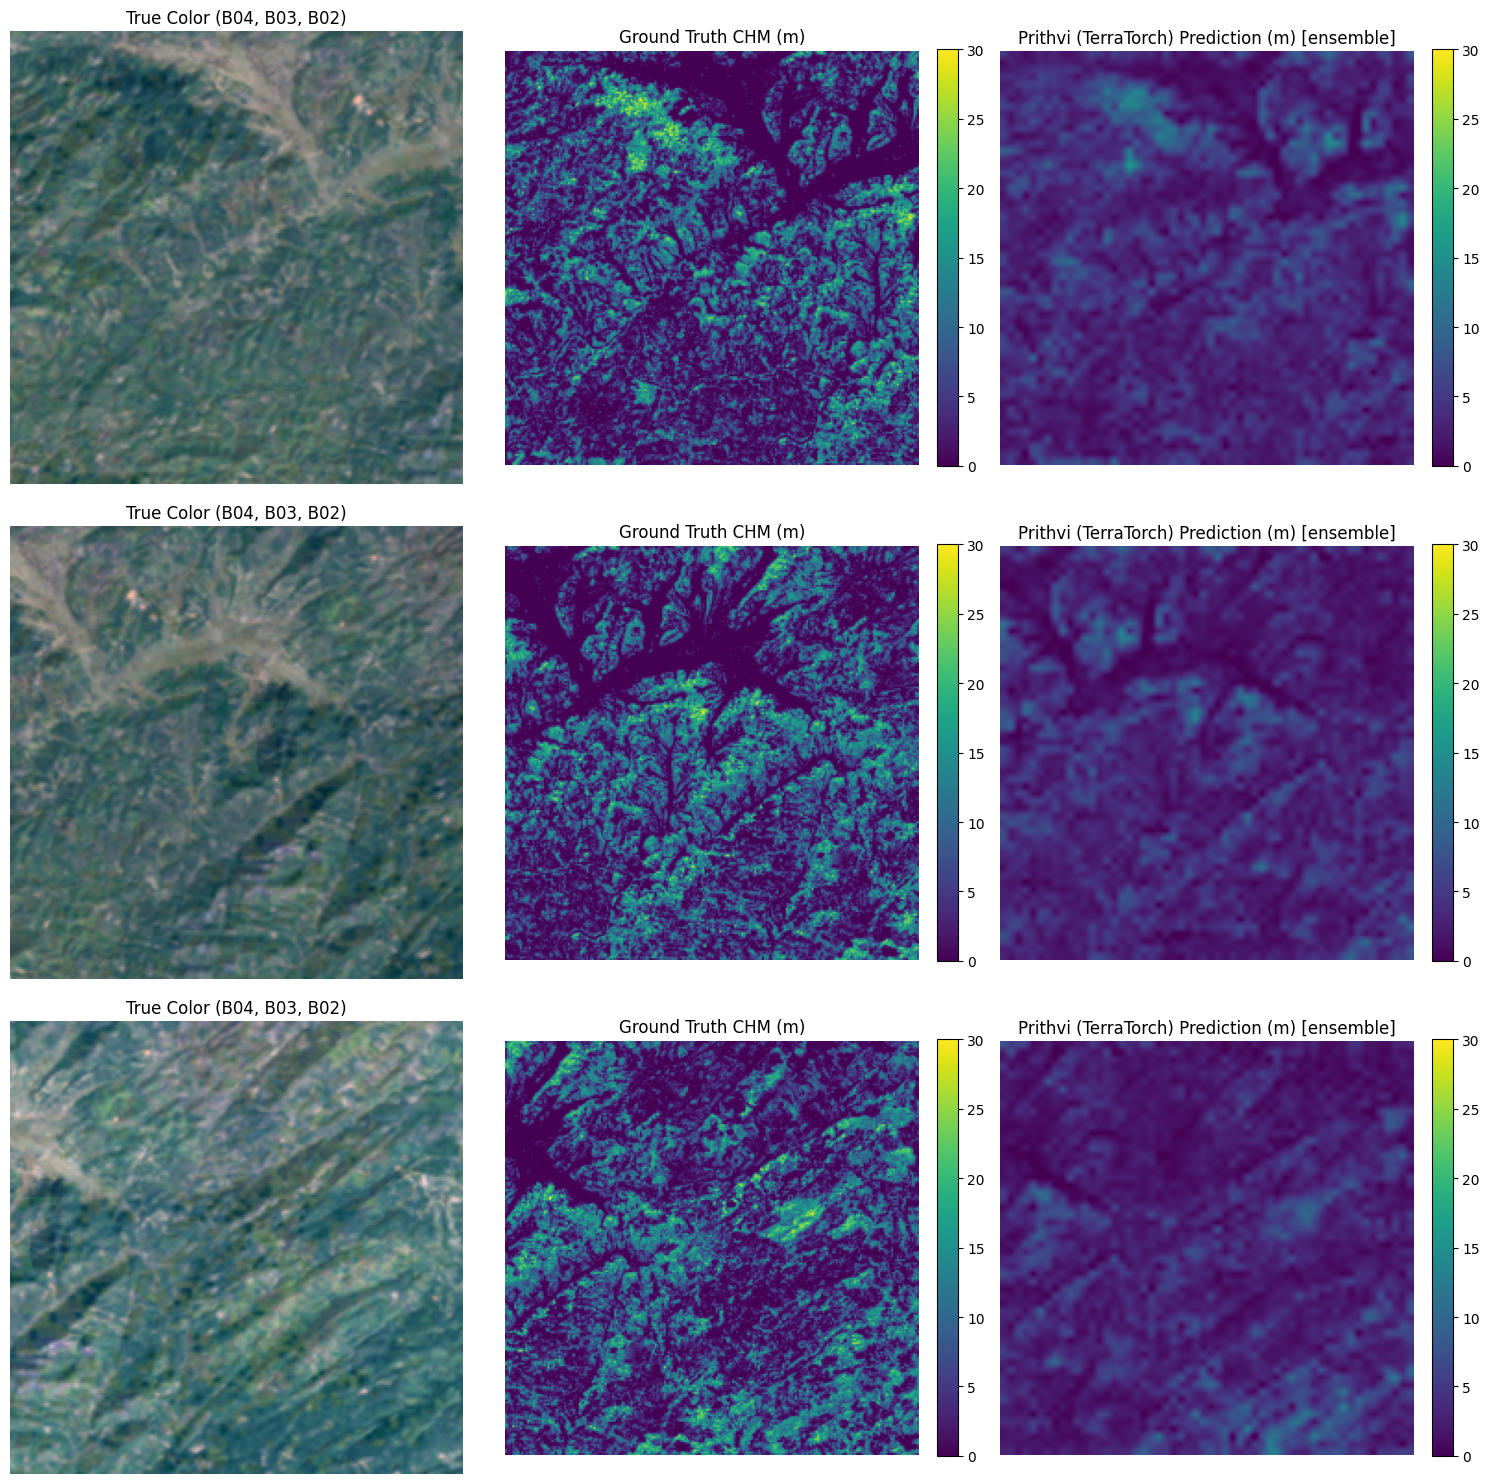

/tmp/ipykernel_11912/1851496291.py:160: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


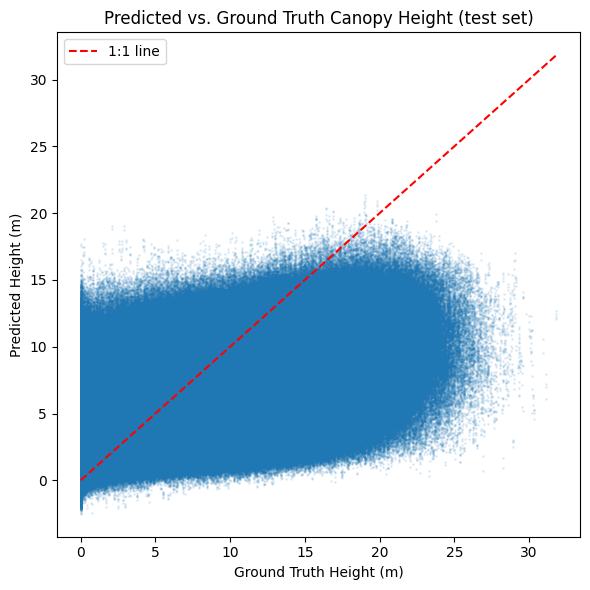

In [ ]:
# --- Final, one-time evaluation on the held-out test set ---
print(f"Ensembling {len(ensemble_model_paths)} checkpoints")


def ensemble_predict(model, checkpoint_paths, loader):
    """Averages continuous height predictions across multiple checkpoints.
    Relies on `loader` not shuffling (true for test_loader) so each
    checkpoint's per-batch predictions line up with the same underlying chips.
    """
    summed_preds = None
    all_targets = None
    for path in checkpoint_paths:
        model.load_state_dict(torch.load(path))
        model.eval()
        batch_preds, batch_targets = [], []
        with torch.no_grad():
            for batch in loader:
                images = batch["image"].to(device)
                targets = batch["target"]
                preds = forward_output(model, images)
                batch_preds.append(preds.cpu())
                batch_targets.append(targets)
        preds_cat = torch.cat(batch_preds)
        summed_preds = preds_cat if summed_preds is None else summed_preds + preds_cat
        if all_targets is None:
            all_targets = torch.cat(batch_targets)
    return summed_preds / len(checkpoint_paths), all_targets


ensemble_preds, all_test_targets = ensemble_predict(model, ensemble_model_paths, test_loader)
test_metrics = compute_regression_metrics(ensemble_preds, all_test_targets)
print(
    f"FINAL TEST METRICS (ensembled) | RMSE: {test_metrics['rmse']:.2f}m, MAE: {test_metrics['mae']:.2f}m, "
    f"Bias: {test_metrics['bias']:+.2f}m, R2: {test_metrics['r2']:.3f}"
)

# For comparison: the single final all-data model alone -- shows how much
# the ensemble is actually contributing.
model.load_state_dict(torch.load(best_model_path))
model.eval()
single_preds_list = []
with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        single_preds_list.append(forward_output(model, images).cpu())
single_preds = torch.cat(single_preds_list)
single_metrics = compute_regression_metrics(single_preds, all_test_targets)
print(
    f"  (single final model only, for comparison) RMSE: {single_metrics['rmse']:.2f}m, "
    f"MAE: {single_metrics['mae']:.2f}m, Bias: {single_metrics['bias']:+.2f}m, R2: {single_metrics['r2']:.3f}"
)


def compute_aggregate_height_stats(preds, targets, ignore_value=IGNORE_VALUE, canopy_threshold=2.0):
    """Aggregate (whole-area) height statistics, as distinct from per-pixel
    error metrics like RMSE. Reports mean/median height, plus a derived
    "canopy cover" fraction (% of pixels above canopy_threshold meters) --
    a standard forestry framing, and a direct echo of the earlier bamboo
    project's aggregate bamboo/non-bamboo percentage request, now in a
    continuous-height context.
    """
    valid = targets != ignore_value
    t = targets[valid]
    p = preds[valid]
    return {
        "true_mean_height": t.mean().item(),
        "pred_mean_height": p.mean().item(),
        "true_median_height": t.median().item(),
        "pred_median_height": p.median().item(),
        "true_canopy_cover_pct": 100 * (t > canopy_threshold).float().mean().item(),
        "pred_canopy_cover_pct": 100 * (p > canopy_threshold).float().mean().item(),
    }


agg_stats = compute_aggregate_height_stats(ensemble_preds, all_test_targets)
print("\nAggregate Height Statistics (test set, ensembled predictions, valid pixels only)")
print(f"  {'Metric':<24} {'Ground Truth':>14} {'Predicted':>12}")
print(f"  {'Mean height (m)':<24} {agg_stats['true_mean_height']:>13.2f} {agg_stats['pred_mean_height']:>11.2f}")
print(f"  {'Median height (m)':<24} {agg_stats['true_median_height']:>13.2f} {agg_stats['pred_median_height']:>11.2f}")
print(f"  {'Canopy cover % (>2m)':<24} {agg_stats['true_canopy_cover_pct']:>12.2f}% {agg_stats['pred_canopy_cover_pct']:>10.2f}%")
print(
    "  NOTE: RMSE/MAE above measure per-pixel agreement; this table measures overall "
    "distribution/coverage, which can look fine even when individual pixels don't line up well, "
    "and vice versa -- report both."
)


def evaluate_and_plot(model, dataloader, num_samples=3, checkpoint_paths=None, vmax=30.0):
    imgs_list, targets_list = [], []
    for batch in dataloader:
        for b in range(batch["image"].shape[0]):
            if len(imgs_list) >= num_samples:
                break
            imgs_list.append(batch["image"][b])
            targets_list.append(batch["target"][b])
        if len(imgs_list) >= num_samples:
            break
    imgs = torch.stack(imgs_list).to(device)
    targets = torch.stack(targets_list).numpy()

    if checkpoint_paths:
        summed_preds = None
        for path in checkpoint_paths:
            model.load_state_dict(torch.load(path))
            model.eval()
            with torch.no_grad():
                preds = forward_output(model, imgs)
            summed_preds = preds if summed_preds is None else summed_preds + preds
        preds = (summed_preds / len(checkpoint_paths)).cpu().numpy()
    else:
        model.eval()
        with torch.no_grad():
            preds = forward_output(model, imgs).cpu().numpy()

    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for b in range(num_samples):
        rgb = imgs[b, [2, 1, 0], 0].cpu().numpy().transpose(1, 2, 0)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)

        axes[b, 0].imshow(rgb)
        axes[b, 0].set_title("True Color (B04, B03, B02)")
        axes[b, 0].axis("off")

        gt = np.ma.masked_where(targets[b] == IGNORE_VALUE, targets[b])
        im1 = axes[b, 1].imshow(gt, cmap="viridis", vmin=0, vmax=vmax)
        axes[b, 1].set_title("Ground Truth CHM (m)")
        axes[b, 1].axis("off")
        plt.colorbar(im1, ax=axes[b, 1], fraction=0.046, pad=0.04)

        im2 = axes[b, 2].imshow(preds[b], cmap="viridis", vmin=0, vmax=vmax)
        axes[b, 2].set_title("Prithvi (TerraTorch) Prediction (m)" + (" [ensemble]" if checkpoint_paths else ""))
        axes[b, 2].axis("off")
        plt.colorbar(im2, ax=axes[b, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


evaluate_and_plot(model, test_loader, num_samples=3, checkpoint_paths=ensemble_model_paths)

# Scatter plot: predicted vs. true height, the standard regression diagnostic
# -- shows systematic bias (points off the 1:1 line) and variance
# (scatter width) at a glance, in a way RMSE alone doesn't.
valid_mask = all_test_targets != IGNORE_VALUE
plt.figure(figsize=(6, 6))
plt.scatter(
    all_test_targets[valid_mask].numpy(),
    ensemble_preds[valid_mask].numpy(),
    s=1, alpha=0.1,
)
max_val = max(all_test_targets[valid_mask].max().item(), ensemble_preds[valid_mask].max().item())
plt.plot([0, max_val], [0, max_val], "r--", label="1:1 line")
plt.xlabel("Ground Truth Height (m)")
plt.ylabel("Predicted Height (m)")
plt.title("Predicted vs. Ground Truth Canopy Height (test set)")
plt.legend()
plt.tight_layout()
plt.show()
